ML Classification Project
Objective
The objective of this project is to build and evaluate a supervised machine learning classification model using the Breast Cancer Wisconsin dataset.

This project demonstrates the complete machine learning workflow, including:

Data loading and preprocessing
Exploratory analysis
Feature scaling
Train-test split
Cross-validation
Building multiple classification models
Comparing model performance
Evaluating models using Accuracy, Precision, Recall, F1-score and ROC-AUC
Two machine learning algorithms are implemented:

Logistic Regression
Random Forest Classifier
The final model is selected based on evaluation metrics and predictive performance.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


Dataset Description
The Breast Cancer Wisconsin Diagnostic Dataset is a binary classification dataset available in Scikit-learn.

The dataset contains measurements computed from digitized images of breast mass cell nuclei.

Target Classes:

0 → Malignant
1 → Benign
This dataset contains:

569 observations
30 numerical features
No missing values
It is commonly used for evaluating classification algorithms.

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Shape of Dataset:", X.shape)

X.head()

Shape of Dataset: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Data Exploration
Before building the machine learning models, it is important to understand the dataset.

In this section we examine:

Dataset information
Data types
Missing values
Statistical summary

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
X.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Observation
The dataset contains no missing values.

All features are numerical, making the dataset suitable for supervised classification after feature scaling.

Data Preprocessing
Machine learning algorithms generally perform better when features are standardized.

The following preprocessing steps are performed:

Train-Test Split
Feature Scaling using StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (455, 30)
Testing Samples: (114, 30)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


Model 1 - Logistic Regression
Logistic Regression is one of the most widely used supervised classification algorithms.

It estimates the probability that an observation belongs to a particular class.

The model is trained using the standardized training dataset.

In [ ]:
lr = LogisticRegression(max_iter=500)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.9790209790209791
ROC-AUC  : 0.99737962659679


In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



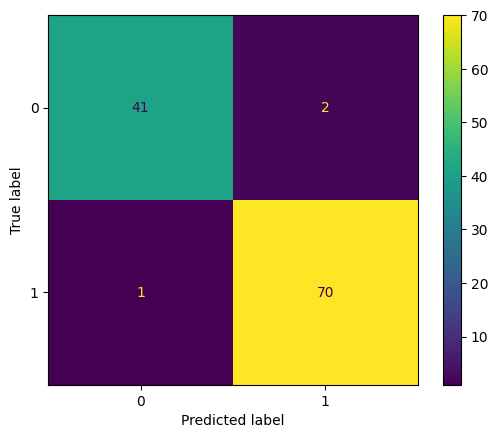

In [ ]:
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

plt.show()

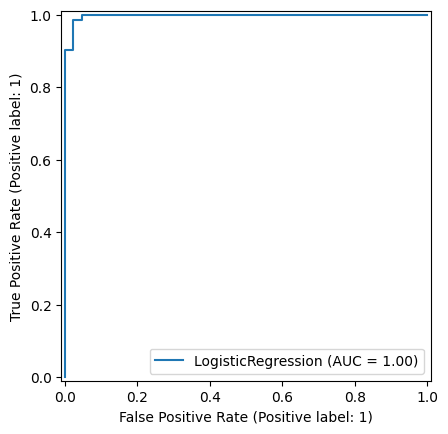

In [ ]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)

plt.show()

Model 2 - Random Forest Classifier
Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions.

It is capable of handling complex relationships between features while reducing overfitting.

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Accuracy : 0.9649122807017544
Precision: 0.958904109589041
Recall   : 0.9859154929577465
F1 Score : 0.9722222222222222
ROC-AUC  : 0.995250573206682


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



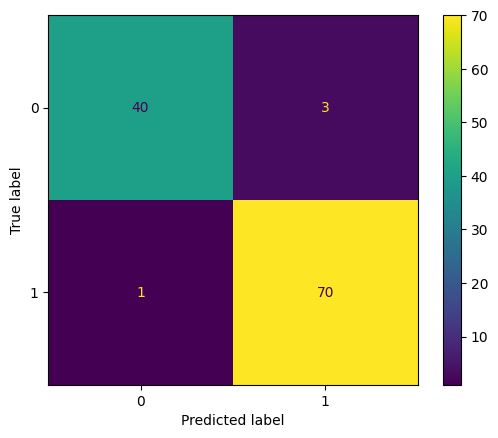

In [ ]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.show()

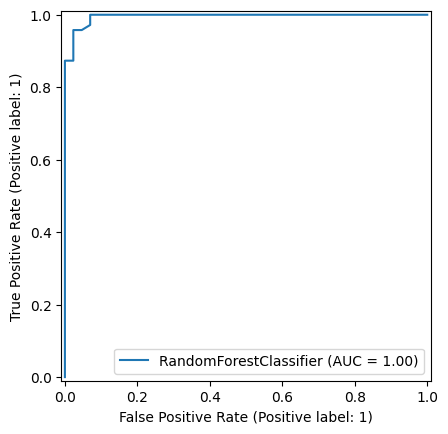

In [ ]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.show()

Cross Validation
Cross-validation provides a more reliable estimate of model performance by evaluating the model across multiple train-test splits.

A 5-fold cross-validation approach is used in this project.

In [ ]:
scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:")

print(scores)

print("\nAverage Accuracy:", scores.mean())

Cross Validation Scores:
[0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]

Average Accuracy: 0.9560937742586555


Feature Importance
Random Forest provides feature importance scores that indicate which features contribute the most to prediction.

The following visualization displays the ten most important features.

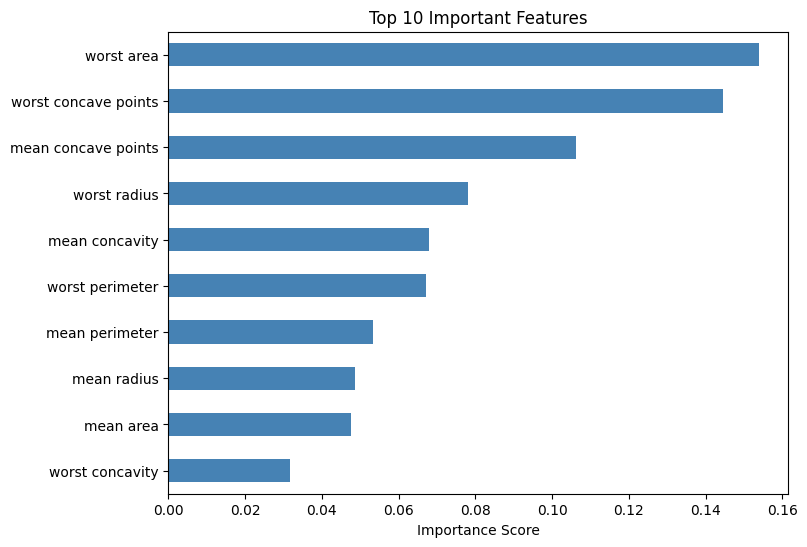

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=data.feature_names
)

importance.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,6),
    color="steelblue"
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.show()

Model Comparison
The performance of Logistic Regression and Random Forest is compared using common classification evaluation metrics.

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973684,0.972222,0.985915,0.979021,0.997380
1,Random Forest,0.964912,0.958904,0.985915,0.972222,0.995251


Conclusion
In this project, two supervised machine learning algorithms were implemented and evaluated using the Breast Cancer Wisconsin dataset.

The project successfully completed:

Data preprocessing
Feature scaling
Train-test splitting
Cross-validation
Logistic Regression model
Random Forest model
Performance evaluation using Accuracy, Precision, Recall, F1-score, and ROC-AUC
Based on the evaluation metrics, the better-performing model can be selected for future predictions.

This project demonstrates a complete end-to-end machine learning classification workflow and satisfies the internship task requirements.